In [1]:
import sys
!{sys.executable} -m pip install torch torch-geometric scikit-learn pandas matplotlib seaborn networkx

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import torch
import torch_geometric
from torch_geometric.datasets import Planetoid

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("Import successful!")

: 

### Install and import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import Planetoid

C:\Users\SAYAN NANDI\AppData\Roaming\Python\Python313\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

### Load the CORA citation graph

In [3]:
dataset = Planetoid(root="data/Planetoid", name="Cora")

Processing...
Done!


In [ ]:
data = dataset[0]
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [ ]:
print(f"Number of Papers(Nodes): {data.num_nodes}")
print(f"Number of edges(Citations): {data.num_edges}")
print(f"Features per paper: {data.num_features}")
print(f"No of topics: {dataset.num_classes}")
print(f"Train Papers: {data.train_mask.sum()}")
print(f"Test Papers: {data.test_mask.sum()}")
print(f"Validation Papers: {data.val_mask.sum()}")

Number of Papers(Nodes): 2708
Number of edges(Citations): 10556
Features per paper: 1433
No of topics: 7
Train Papers: 140
Test Papers: 1000
Validation Papers: 500


### Inspect Citation Network Structure

In [ ]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

In [ ]:
topic_counts

,count
0,351
1,217
2,418
3,818
4,426
5,298
6,180


<Axes: xlabel='None', ylabel='count'>

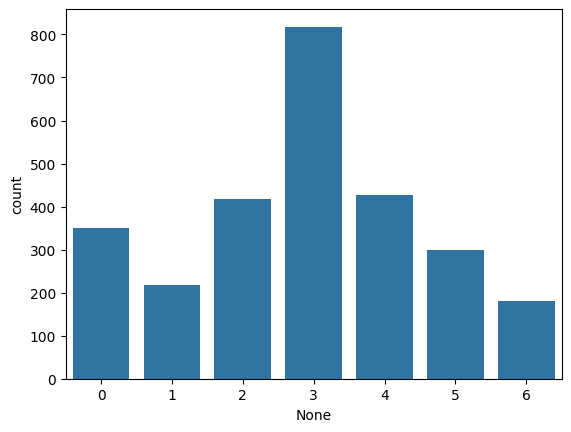

In [ ]:
sns.barplot(x=topic_counts.index, y=topic_counts)

### Baseline: TF-IDF style features plus Random Forest

In [ ]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [ ]:
X_binary

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.numpy()
test_idx = data.test_mask.numpy()
val_idx = data.val_mask.numpy()

X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx], y[test_idx]

rf = RandomForestClassifier(n_estimators=100, max_features="sqrt", class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="macro")

print(f"Accuracy score: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro f1 score: {f1_score(y_test, rf_pred, average="macro"):.4f}")

Accuracy score: 0.5800
Macro f1 score: 0.5818


<Axes: >

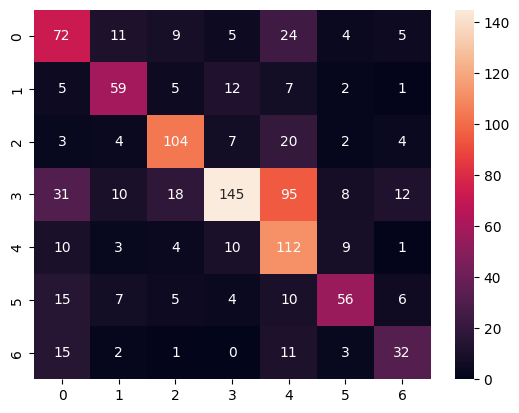

In [ ]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")

### Advanced Model : A two layer GCN

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
class SimpleGCN(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
    super().__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 = GCNConv(hidden_dim, output_dim)
    self.dropout = dropout

  def forward(self, x, edge_index):
    x = self.conv1(x, edge_index)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.conv2(x, edge_index)
    return x


model = SimpleGCN(
      input_dim = data.num_features,
      hidden_dim = 32,
      output_dim = dataset.num_classes
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [ ]:
# Training of GCN model
def train_one_epoch():
  model.train()
  optimizer.zero_grad()
  logits = model(data.x, data.edge_index)
  loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()

    logits = model(data.x, data.edge_index)

    # Select only nodes belonging to the given mask
    predictions = logits[mask].argmax(dim=1)

    # Calculate accuracy
    accuracy = (predictions == data.y[mask]).float().mean().item()

    # Calculate Macro F1
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions.numpy(),
        average="macro"
    )

    return accuracy, macro_f1, predictions

In [ ]:
losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20

for epoch in range(1, 201):
  loss = train_one_epoch()
  train_accuracy,_,_ = evaluate(data.train_mask)
  val_accuracy,_,_ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy)

  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_state = model.state_dict()
    epoch_without_improvement = 0
  else:
    epoch_without_improvement += 1

  if epoch_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train accuracy: {train_accuracy:.4f} | Val accuracy: {val_accuracy:.4f} | Best val accuracy: {best_val_accuracy:.4f}")

model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_preds = evaluate(data.test_mask)

print(f"GCN Test Accuracy: {gcn_accuracy:.4f}")
print(f"GCN Test Macro F1: {gcn_f1:.4f}")

Epoch: 001 | Loss: 0.0001 | Train accuracy: 1.0000 | Val accuracy: 0.7580 | Best val accuracy: 0.7580
Epoch: 010 | Loss: 0.0003 | Train accuracy: 1.0000 | Val accuracy: 0.7580 | Best val accuracy: 0.7580
Epoch: 020 | Loss: 0.0000 | Train accuracy: 1.0000 | Val accuracy: 0.7600 | Best val accuracy: 0.7620
Epoch: 030 | Loss: 0.0000 | Train accuracy: 1.0000 | Val accuracy: 0.7580 | Best val accuracy: 0.7620
Early stopping at epoch 33
GCN Test Accuracy: 0.7790
GCN Test Macro F1: 0.7747


### Compare the models

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "GCN"],
    "Accuracy": [rf_accuracy, gcn_accuracy],
    "Macro f1": [rf_f1, gcn_f1],
})

results

,Model,Accuracy,Macro f1
0,Random Forest,0.580,0.581814
1,GCN,0.779,0.774682


In [ ]:
# ONNX -> Open neural network exchange -> Model very fast and optimized.
import torch
#!pip install onnxscript

# Set the model to evaluation mode
model.eval()

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "simple_gcn_cora.onnx"
torch.onnx.export(
    # trained model
    model,
    # model input
    (x_dummy, edge_index_dummy),
    # Where to save the ONNX model
    onnx_file_path,
    # Store the trained parameter weights inside the model file
    export_params=True,
    # Changed the opset version to 18
    opset_version=18,
    # Whether to execute constant folding for optimization
    do_constant_folding=True,
    # input names
    input_names = ["node_features", "edge_indices"],
    # output names
    output_names = ["logits"],
    # Variable length for num_nodes
    dynamic_axes = {
        'node_features': {0: 'num_nodes'},
        'edge_indices': {1: 'num_edges'}
    }
    # Variable length for num_edges
)

/tmp/ipykernel_1280/696382405.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.11.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"node_features"<FLOAT,[num_nodes,1433]>,
                %"edge_indices"<INT64,[2,num_edges]>
            ),
            outputs=(
                %"logits"<FLOAT,[num_nodes,7]>
            ),
            initializers=(
                %"conv1.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"conv1.lin.weight"<FLOAT,[32,1433]>{TorchTensor(...)},
                %"conv2.bias"<FLOAT,[7]>{TorchTensor<FLOAT,[7]>(Parameter containing: tensor([-0.2632, -0.1337, -0.2090, -0.2961, -0.2034,  0.3198,  0.2471], requires_grad=True), name='conv2.bias')},
                %"conv2.lin.weight"<FLOAT,[7,32]>{TorchTensor(...)},
                %"val_5"<INT64,[]>{Tensor<INT64,[]>(